# Utilizar otro dataset y poner en práctica la generación de secuencias con la estategias presentadas.

In [90]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
import nltk
from tensorflow.keras.preprocessing.text import text_to_word_sequence
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences # se utilizará para padding
import keras

In [28]:
nltk.set_proxy('http://127.0.0.1:3128')
nltk.download('mte_teip5')
nltk.download('punkt')

[nltk_data] Downloading package mte_teip5 to /home/l30659/nltk_data...
[nltk_data]   Unzipping corpora/mte_teip5.zip.
[nltk_data] Downloading package punkt to /home/l30659/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [51]:
orwell_sents = nltk.corpus.multext_east.sents('oana-en.xml')
str(orwell_sents[0])

"['It', 'was', 'a', 'bright', 'cold', 'day', 'in', 'April', ',', 'and', 'the', 'clocks', 'were', 'striking', 'thirteen', '.']"

In [78]:
nltk.word_tokenize(' '.join(orwell_sents[0]))

['It',
 'was',
 'a',
 'bright',
 'cold',
 'day',
 'in',
 'April',
 ',',
 'and',
 'the',
 'clocks',
 'were',
 'striking',
 'thirteen',
 '.']

In [77]:
# Se tuvo la intención de usar word_tokenizer de ntlk, sin embargo, esta función no elimina las puntuaciónes ni convierte el texto en minúscula. Por lo tanto se decidió utilizar text_to_word_sequence de keras
segmented_sentences = [text_to_word_sequence(' '.join(orwell_sent)) for orwell_sent in orwell_sents]
print(segmented_sentences[0])

['it', 'was', 'a', 'bright', 'cold', 'day', 'in', 'april', 'and', 'the', 'clocks', 'were', 'striking', 'thirteen']


In [62]:
length_sentences = [len(sentence) for sentence in segmented_sentences]

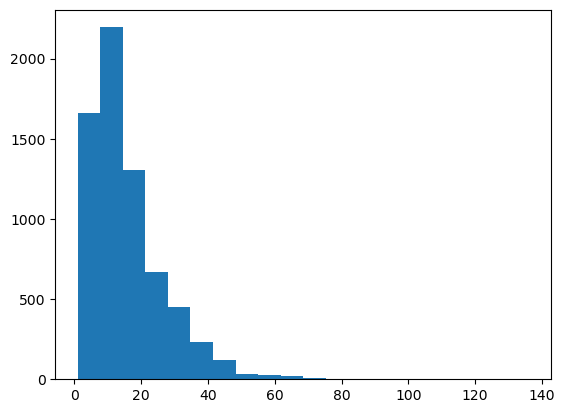

In [66]:
# podemos ver su distribución
plt.hist(length_sentences,bins=20)
plt.show()

In [76]:
# a partir de la distribución de longitudes de secuencias elegimos algún criterio
# para determinar el máximo tamaño de contexto. En este caso es un percentil, pero
# otros criterios también pueden ser válidos con la justificación adecuada.

# el -1 es porque el último token será el target
max_context_size = int(np.percentile(length_sentences, 85)-1)
# max_context_size = int(np.ceil(np.mean(length_sentences))) # criterio de media
# max_context_size = int(np.ceil(np.median(length_sentences))) # criterio de mediana
print(f'max_context_size: {max_context_size}')

max_context_size: 25


###  Tokenizar

In [81]:
# instanciamos el tokenizador
tok = Tokenizer()

# El tokenizer "aprende" las palabras que se usaran
# Se construye (fit) una vez por proyecto, se aplica N veces (tal cual un encoder)
# El token 0 es reservado y no es asignado. Se utiliza para designar a palabras
# fuera del vocabulario aprendido
tok.fit_on_texts(segmented_sentences)

# Convertimos las palabras a números
# entran palabras -> salen números
tokenized_sentences = tok.texts_to_sequences(segmented_sentences)

In [83]:
tokenized_sentences[0]

[8, 6, 3, 1426, 510, 141, 9, 1839, 4, 1, 3434, 22, 3435, 4903]

In [85]:
tokenized_sentences_train, tokenized_sentences_val, _, _ = train_test_split(tokenized_sentences, tokenized_sentences, test_size=0.2, random_state=42)


In [86]:
len(tokenized_sentences_train)

5389

In [87]:
tok_sent = []

for sent in tokenized_sentences_train:

  # si la secuencia tiene más términos que el tamaño de contexto máximo,
  # armo varias sub-secuencias de tamaño máximo
  if len(sent) > (max_context_size+1):
    extra = len(sent)-(max_context_size+1) + 1
    for i in range(extra):
      tok_sent.append(sent[i:i+max_context_size+1])
  else: # si la secuencia tiene menos términos el tamaño de contexto máximo, dejo la secuencia como está
    tok_sent.append(sent)

In [88]:
len(tok_sent)

14115

In [91]:
tok_sent_augm = []

for sent in tok_sent:

  # generamos todas las sub-secuencias
  subseq = [sent[:i+2] for i in range(len(sent)-1)]
  # en esta línea paddeamos al tamaño de contexto máximo
  tok_sent_augm.append(pad_sequences(subseq, maxlen=max_context_size+1, padding='pre'))

In [95]:
len(tok_sent_augm.shape)

AttributeError: 'list' object has no attribute 'shape'